# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [30]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [31]:
# Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
''' Creamos una nueva columna de titulo title_length convirtiendo los valores de la columna title
convertimos los valores de esta columna en un string para asegurarnos de que todos sean de este tipo
luego aplicamos la funcion str.len() para obtener la cantidad de caracteres de los titulos y guardar estas cantidades en 
la nueva columna.'''

df["title_length"] = df["title"].astype(str).str.len()
df

,star_rating,title,content_rating,genre,duration,actors_list,title_length
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...",24
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']",13
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv...",22
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E...",15
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L....",12
...,...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G...",7
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma...",27
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo...",47
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr...",11


In [32]:
# Calcula media, mediana y moda de la columna 'title_length'
'''Se calculan la media, mediana y moda con las funciones mean, median y mode respectivamente.
La moda es una serie de pandas con el valor de la moda ubicado en el indice 0 por eso se guarda indexando 0'''
media = df["title_length"].mean()
mediana = df["title_length"].median()
moda = df["title_length"].mode()[0]

print(media)
print(mediana)
print(moda)

15.481103166496425
14.0
12


In [33]:
# Calcula el rango, la varianza y la desviación estándar de 'title_length'
'''Calculamos el rango como la resta de el maximo menos el minimo y las varianza y desviacion estandar
con las funciones var y std respectivamente'''

rango = df["title_length"].max() - df["title_length"].min()
var_sample = df["title_length"].var()  # var muestral 
std_sample = df["title_length"].std()  # std muestral


print("Rango:", rango)
print("Varianza (sample):", var_sample)
print("Desv std (sample):", std_sample)

Rango: 67
Varianza (sample): 72.1067488840288
Desv std (sample): 8.491569282766807


In [34]:
# Calcula asimetría y curtosis de la columna 'title_length'
'''Calculamos asimetria y exceso de curotsis con las funciones skew() y kurt() respectivamente.'''
asimetria = df["title_length"].skew()
curtosis_v = df["title_length"].kurt()

print("Asimetría:", asimetria)
print("Curtosis:", curtosis_v)

Asimetría: 1.5252523464631278
Curtosis: 3.8122887061291544


In [35]:
# Imprime el título más corto y el título más largo según su longitud
'''Ordenamos de menor a mayor usando la funcion sort_values la columna title_lenght y guardamos
en las variables shortest y longest el valor de la columna title en el primer indice y en el 
ultimo indice que corresponderian al titulo mas corto y el mas largo'''

shortest = df.sort_values("title_length").iloc[0]["title"]
longest  = df.sort_values("title_length").iloc[-1]["title"]

print("Título más corto:", shortest)
print("Título más largo:", longest)

Título más corto: M
Título más largo: Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb


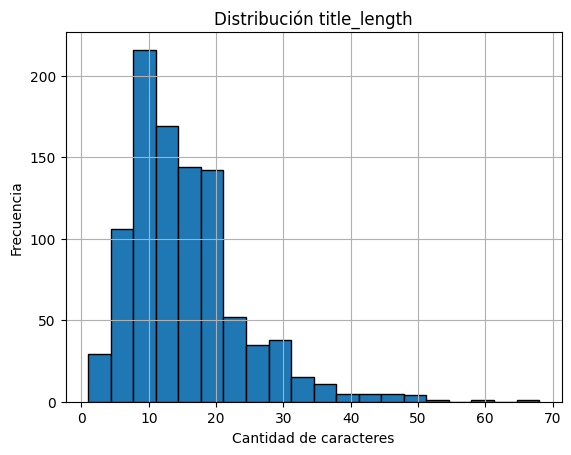

In [36]:
# grafica tus resultados
'''graficamos un histograma de 20 bins de los valores de la columna title_length y notamos que como calculamos
es una grafica leptocurtica y con asimetria positiva. '''
ax = df["title_length"].plot(kind="hist", bins=20, edgecolor="black", title="Distribución title_length")
ax.set_xlabel("Cantidad de caracteres")
ax.set_ylabel("Frecuencia")
plt.grid(True)
plt.show()

---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


In [37]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]
data = np.array([10, 13, 14, 18, 22])

In [ ]:
# Calcula la media de los 5 valores
'''como el calculo es manual sacamos el promedio usando las funciones sum y len 
para dividir la suma de los valores entre la cantidad de valores'''
media_data = sum(data) / len(data)
print(f"Media: {media_data}")

Media: 15.4


In [ ]:
# Calcula las diferencias al cuadrado con respecto a la media
'''ahora calculamos la sumatoria de las diferencia entre cada valor
y la media elevado al cuadrado. Para esto utilizamos un for que le reste la media a cada valor
elevando al cuadrado cada resultado y encerramos en una funcion sum para que sume todos esto valores'''
suma_diferencias = sum(  (x - media_data)**2 for x in data )
print(f"Suma de diferencias al cuadrado: {suma_diferencias}")

Suma de diferencias al cuadrado: 87.19999999999999


In [41]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación\
'''finalmente calculamos la varianza dividiendo la sumatoria entre la cantidad de valores
y la desviacion estandar que es la raiz cuadrada de la varianza'''
varianza_manual = suma_diferencias / len(data)
desviacion_manual = varianza_manual ** 0.5

print(f"Varianza: {varianza_manual}")
print(f"Desviación estándar: {desviacion_manual}")

Varianza: 17.439999999999998
Desviación estándar: 4.176122603564219
